In [93]:
import kagglehub
import pandas as pd
import numpy as np
import os 

# Download latest version
path = "../data"

print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: ../data
['Superstore.csv']


In [94]:
df = pd.read_csv(os.path.join(path, "Superstore.csv"), encoding="latin-1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [95]:
print("Shape:", df.shape)

print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)

df.info()

# df.head()

Shape: (9994, 21)

Columns:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Dtypes:
 Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --

In [96]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [97]:
print("\nDuplicate Rows:", df.duplicated().sum())

df.describe()


Duplicate Rows: 0


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [98]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Row ID: 9994 unique values
Order ID: 5009 unique values
Order Date: 1238 unique values
Ship Date: 1334 unique values
Ship Mode: 4 unique values
Customer ID: 793 unique values
Customer Name: 793 unique values
Segment: 3 unique values
Country: 1 unique values
City: 531 unique values
State: 49 unique values
Postal Code: 631 unique values
Region: 4 unique values
Product ID: 1862 unique values
Category: 3 unique values
Sub-Category: 17 unique values
Product Name: 1841 unique values
Sales: 5825 unique values
Quantity: 14 unique values
Discount: 12 unique values
Profit: 7287 unique values


In [99]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

In [100]:

df['Shipping Duration (Days)'] = (df['Ship Date'] - df['Order Date']).dt.days

In [101]:
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order Day']     = df['Order Date'].dt.day_name()

In [102]:
df.drop(columns=['Row ID'], inplace=True)

In [103]:
print("Missing after cleaning:", df.isnull().sum().sum())

Missing after cleaning: 0


In [104]:
df[['Order Date', 'Ship Date', 'Shipping Duration (Days)', 
    'Order Year', 'Order Month', 'Order Quarter']].head()

,Order Date,Ship Date,Shipping Duration (Days),Order Year,Order Month,Order Quarter
0,2013-11-09,2013-11-12,3,2013,11,4
1,2013-11-09,2013-11-12,3,2013,11,4
2,2013-06-13,2013-06-17,4,2013,6,2
3,2012-10-11,2012-10-18,7,2012,10,4
4,2012-10-11,2012-10-18,7,2012,10,4


In [105]:
print("Rows with Sales <= 0:", (df['Sales'] <= 0).sum())
print("Rows with negative Profit:", (df['Profit'] < 0).sum())

df['Is Loss'] = df['Profit'] < 0
print("\nLoss-making orders:", df['Is Loss'].sum())

Rows with Sales <= 0: 0
Rows with negative Profit: 1871

Loss-making orders: 1871


In [106]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

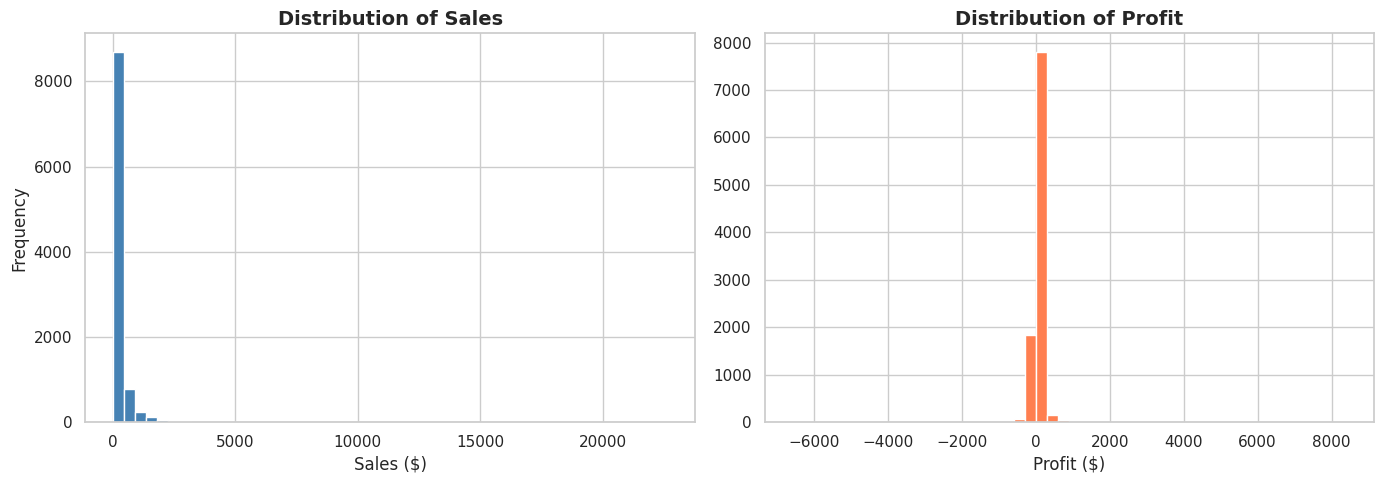

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Sales')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Profit'], bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Profit')
axes[1].set_xlabel('Profit ($)')

plt.tight_layout()
plt.show()

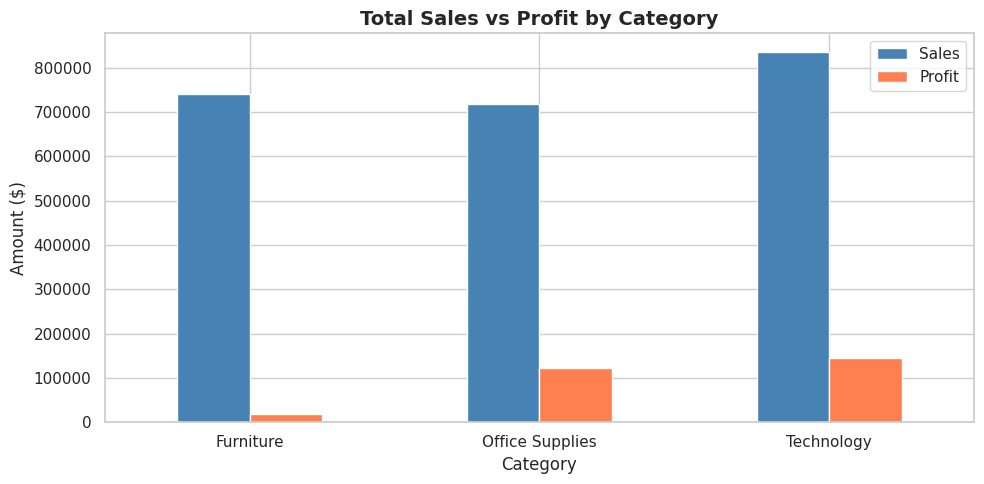

In [108]:
cat_group = df.groupby('Category')[['Sales', 'Profit']].sum()

cat_group.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'coral'], edgecolor='white')
plt.title('Total Sales vs Profit by Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

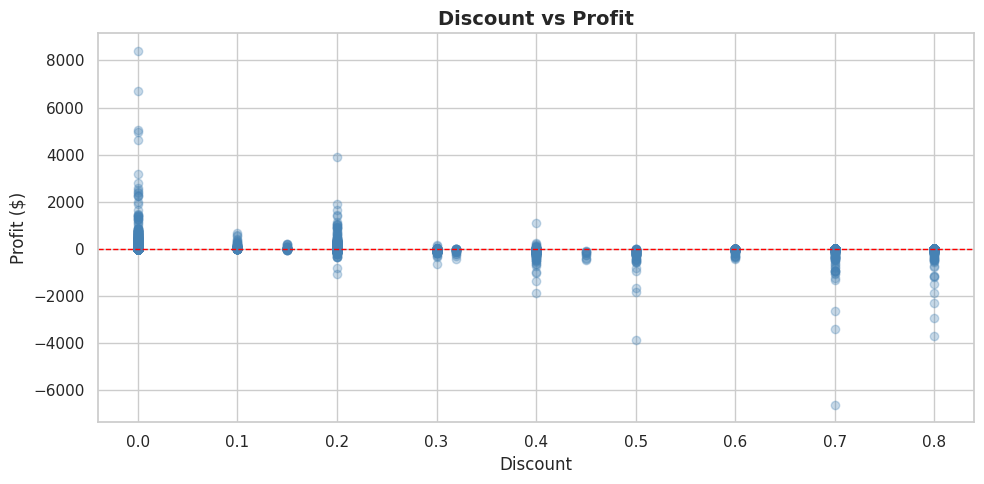

In [109]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, color='steelblue')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.show()

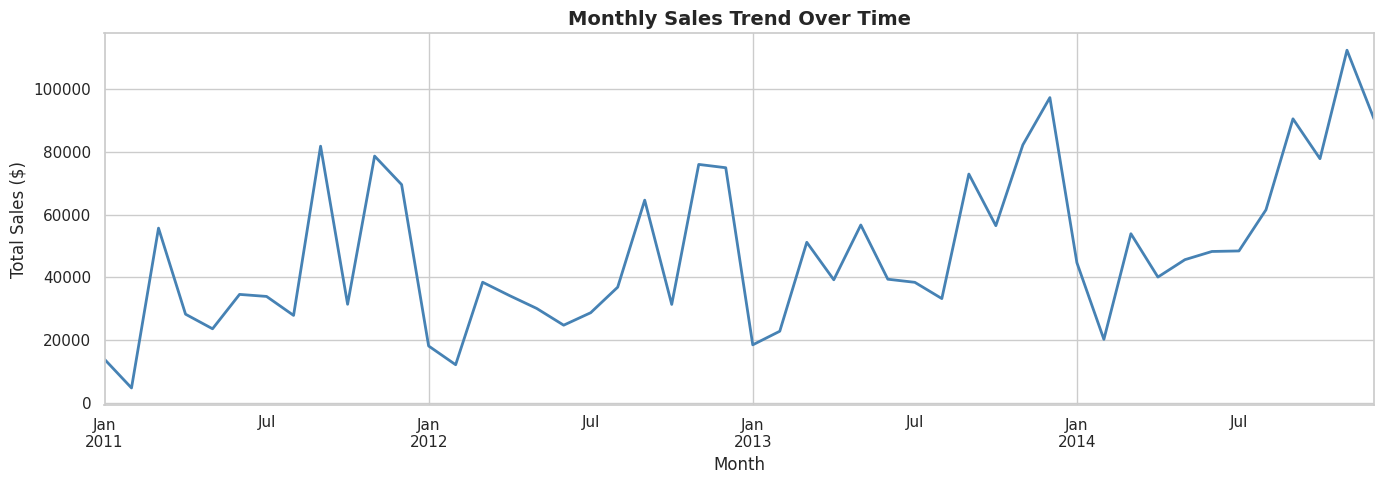

In [110]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(kind='line', figsize=(14, 5), color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

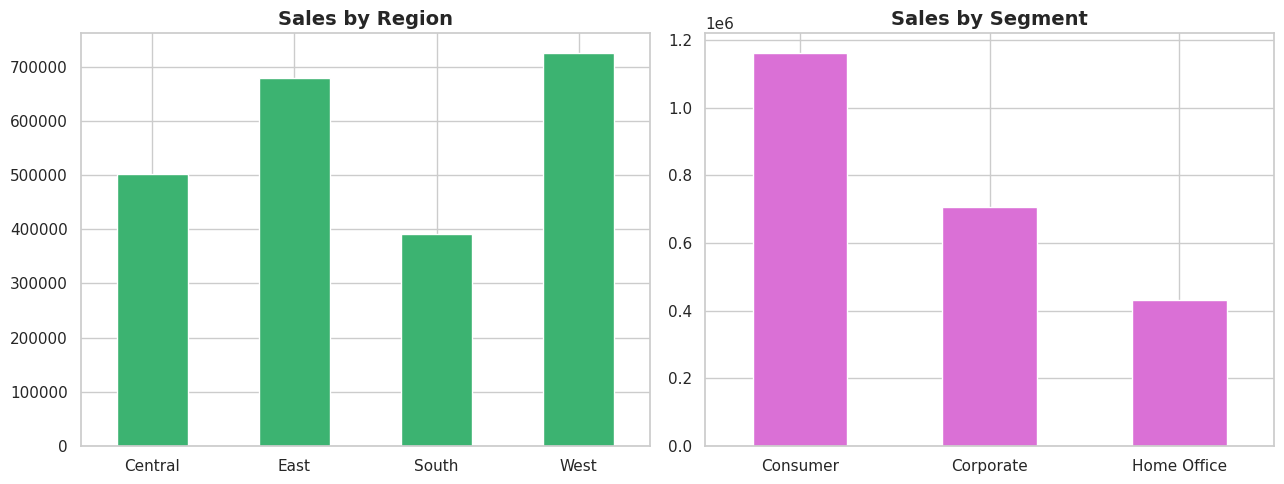

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.groupby('Region')['Sales'].sum().plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Sales by Region')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Segment')['Sales'].sum().plot(kind='bar', ax=axes[1], color='orchid', edgecolor='white')
axes[1].set_title('Sales by Segment')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

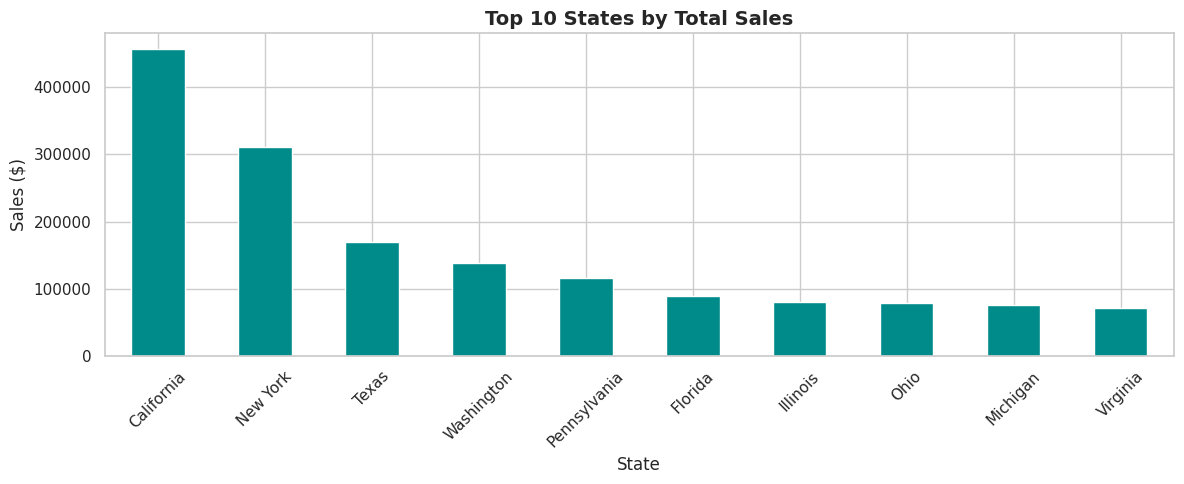

In [112]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

top_states.plot(kind='bar', color='darkcyan', edgecolor='white', figsize=(12, 5))
plt.title('Top 10 States by Total Sales')
plt.ylabel('Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

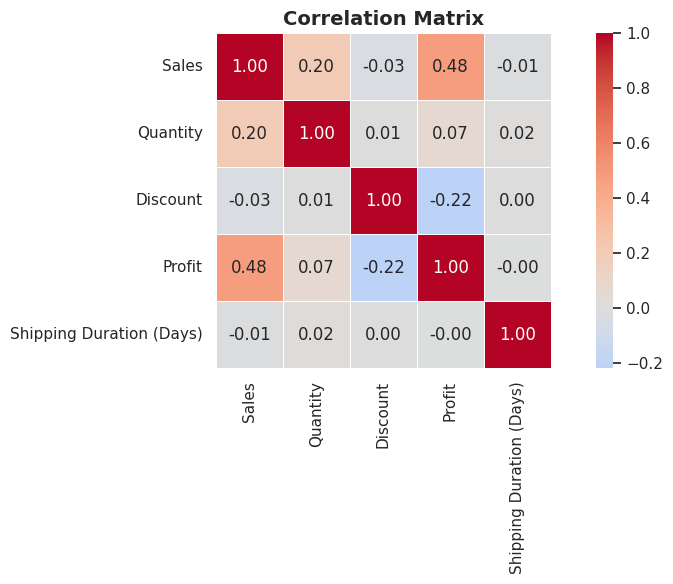

In [113]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Duration (Days)']

corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [114]:
print("=" * 50)
print("      SUPERSTORE — EDA SUMMARY")
print("=" * 50)
print(f"Total Orders:        {len(df):,}")
print(f"Total Revenue:       ${df['Sales'].sum():,.2f}")
print(f"Total Profit:        ${df['Profit'].sum():,.2f}")
print(f"Loss-making Orders:  {(df['Profit'] < 0).sum():,} ({(df['Profit'] < 0).mean()*100:.1f}%)")
print(f"Best Category:       {df.groupby('Category')['Profit'].sum().idxmax()}")
print(f"Worst Sub-Category:  {df.groupby('Sub-Category')['Profit'].sum().idxmin()}")
print(f"Top Region:          {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Date Range:          {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

      SUPERSTORE — EDA SUMMARY
Total Orders:        9,994
Total Revenue:       $2,297,200.86
Total Profit:        $286,397.02
Loss-making Orders:  1,871 (18.7%)
Best Category:       Technology
Worst Sub-Category:  Tables
Top Region:          West
Date Range:          2011-01-04 → 2014-12-31


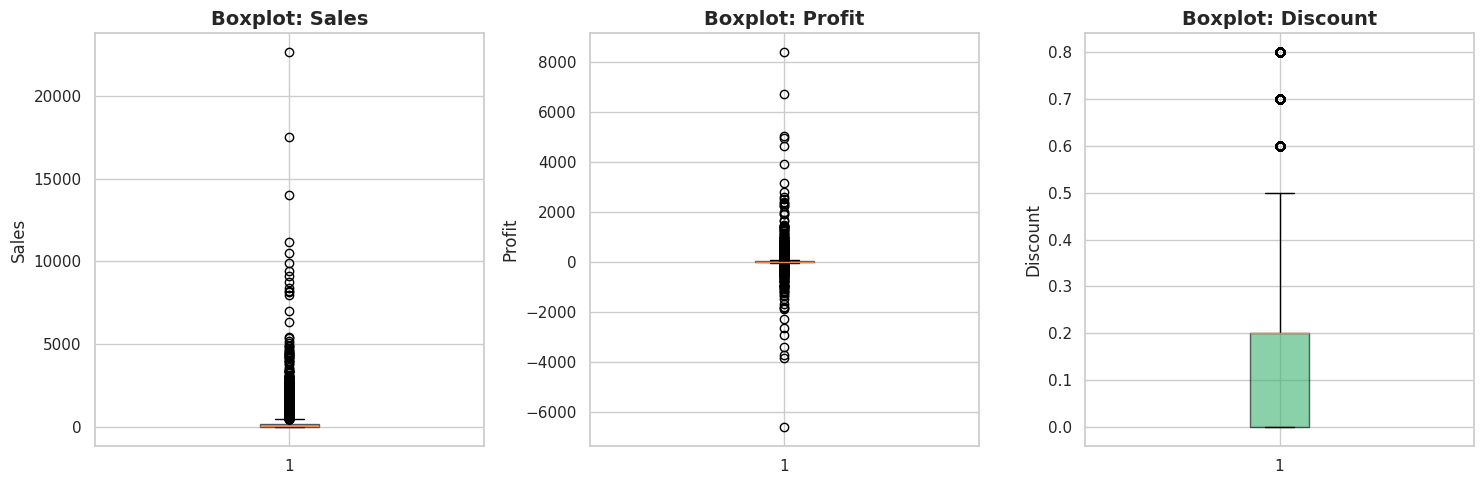

In [115]:
# ── Boxplots for outlier detection ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes, ['Sales', 'Profit', 'Discount'], 
                                 ['steelblue', 'coral', 'mediumseagreen']):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(f'Boxplot: {col}')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

ml_df = df[['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode',
            'Sales', 'Quantity', 'Discount', 'Shipping Duration (Days)',
            'Order Year', 'Order Month', 'Order Quarter', 'Profit']].copy()



In [ ]:
cat_cols = ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']
le = LabelEncoder()

for col in cat_cols:
    ml_df[col + '_encoded'] = le.fit_transform(ml_df[col])

ml_df.drop(columns=cat_cols, inplace=True)


In [ ]:
X = ml_df.drop(columns=['Profit'])
y = ml_df['Profit']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("X shape:", X_scaled_df.shape)
print("y shape:", y.shape)
X_scaled_df.head()

X shape: (9994, 12)
y shape: (9994,)


,Sales,Quantity,Discount,Shipping Duration (Days),Order Year,Order Month,Order Quarter,Category_encoded,Sub-Category_encoded,Segment_encoded,Region_encoded,Ship Mode_encoded
0,0.051510,-0.804303,-0.756643,-0.548867,0.246504,0.969423,1.055977,-1.544978,-0.710815,-0.864161,0.369413,-0.213513
1,0.805633,-0.354865,-0.756643,-0.548867,0.246504,0.969423,1.055977,-1.544978,-0.512842,-0.864161,0.369413,-0.213513
2,-0.345368,-0.804303,-0.756643,0.023540,0.246504,-0.552238,-0.836676,0.043552,0.477027,0.447170,1.229798,-0.213513
3,1.167688,0.544012,1.423149,1.740761,-0.643189,0.665091,1.055977,-1.544978,1.664869,-0.864161,0.369413,0.694896
4,-0.332935,-0.804303,0.212153,1.740761,-0.643189,0.665091,1.055977,0.043552,1.268921,-0.864161,0.369413,0.694896


In [ ]:
from sklearn.model_selection import train_test_split

# ── Train/Validation/Test split (70 / 15 / 15) ─────────
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled_df, y, test_size=0.15, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42)

print(f"Train:      {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test:       {X_test.shape[0]} rows")

Train:      6994 rows
Validation: 1500 rows
Test:       1500 rows
